# ***ENTREGA FINAL***
## **MATERIA**: Métodos Numéricos
## **INTEGRANTES**: Barrios, Julieta Luján - Sappia, Lucio Agustín - Tartarini, Luciano Aquiles
## **FECHA**: 23 de junio, 2026

# ***FASE 1: Implementación de Solvers y Simulación Base***

En esta primera etapa del proyecto, el objetivo es implementar los solvers numéricos para resolver el Problema de Valor Inicial (PVI) de nuestro Modelo de Saturación con Olvido.

Evaluaremos la evolución temporal de la población informada a lo largo de un horizonte de simulación completo de T=15 días.  

Para esto, configuraremos el sistema con los parámetros poblacionales y constantes especificados para el problema asignado: una población total de P = 100000, una condición inicial de y_0 = 100 agentes, una tasa de contagio base de β = 3×10^−6 y una tasa de olvido de δ = 0.1.  

Compararemos gráficamente la precisión y estabilidad de tres métodos numéricos: Euler, Runge-Kutta de 4to orden (RK4) y Adams-Bashforth de 2 pasos (AB2). El método AB2, al ser multipaso, requiere un tratamiento especial: utilizaremos un paso simple de RK4 para generar el punto de arranque necesario. Finalmente, contrastaremos estos solvers variando el tamaño de paso numérico, empleando inicialmente h = 0.1 y h = 0.01.

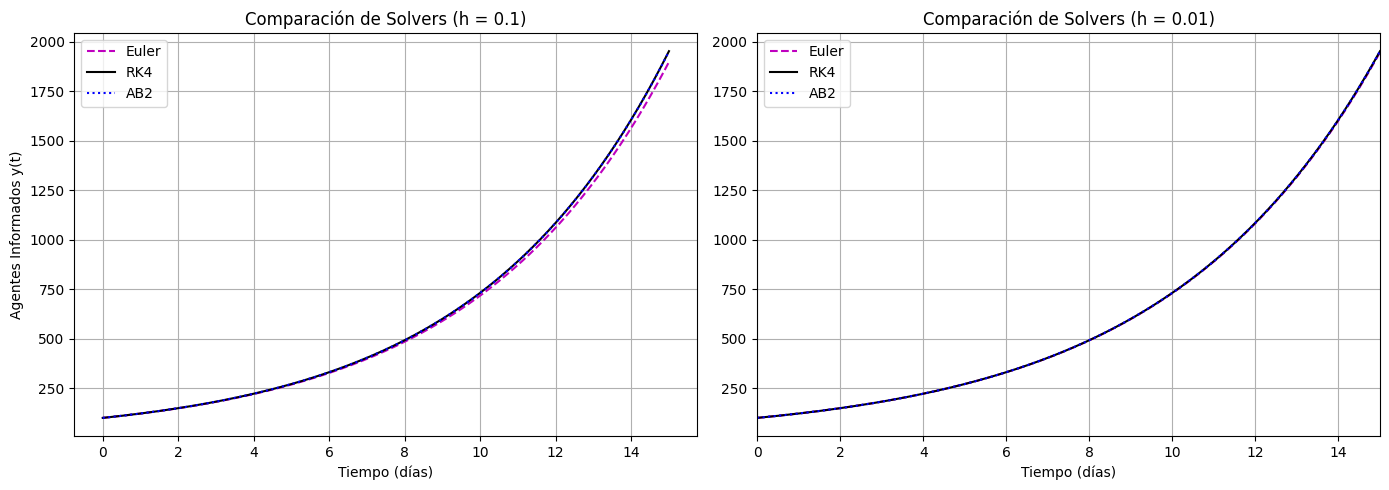

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. Parámetros del Modelo - (Modelo con Olvido)
# =====================================================================
P = 100000        # Población total susceptible
beta = 3.0e-6     # Tasa de contagio viral inicial (Fase 1)
delta = 0.1       # Tasa de olvido o desinterés
y0 = 100          # Estado inicial de la red (agentes informados)
t0 = 0            # Día de inicio
T = 15            # Horizonte temporal final en días

# =====================================================================
# 2. Definición del PVI
# =====================================================================
def fcn(t, y):
    """
    Ecuación Diferencial: dy/dt = beta * y * (P - y) - delta * y
    Representa el crecimiento logístico con un término de decaimiento.
    """
    return beta * y * (P - y) - delta * y

# =====================================================================
# 3. Solvers Numéricos
# =====================================================================

def euler(fcn, a, b, y0, N):
    """
    Método de Euler (orden p=1).
    Es un esquema explícito de un paso que aproxima la solución trazando
    la recta tangente en cada punto. En este proyecto lo utilizamos
    principalmente como referencia base para ilustrar cómo se degrada el
    error numérico cuando se utilizan pasos grandes (h).
    """
    h = (b - a) / N # Tamaño del paso
    t = a + np.arange(N + 1) * h
    y = np.zeros(t.size) # Preasignación de memoria
    y[0] = y0
    for k in range(N):
        y[k+1] = y[k] + h * fcn(t[k], y[k])
    return t, y

def rk4(fcn, a, b, y0, N):
    """
    Método de Runge-Kutta de 4to Orden (orden p=4).
    Es un método de paso simple de alta precisión que evalúa la pendiente
    en cuatro puntos distintos dentro del intervalo para calcular un
    promedio ponderado. Actúa como nuestro solver principal por su
    estabilidad y se utiliza además como generador del punto de arranque
    para el método multipaso AB2.
    """
    h = (b - a) / N
    t = a + np.arange(N + 1) * h
    y = np.zeros(t.size)
    y[0] = y0
    for k in range(N):
        k1 = fcn(t[k], y[k])
        k2 = fcn(t[k] + h/2, y[k] + h * k1/2)
        k3 = fcn(t[k] + h/2, y[k] + h * k2/2)
        k4 = fcn(t[k] + h, y[k] + h * k3)
        y[k + 1] = y[k] + h * (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y

def ab2(fcn, a, b, y0, N):
    """
    Método de Adams-Bashforth de 2 pasos (orden p=2).
    Es un método multipaso explícito que requiere de dos puntos históricos
    para calcular el siguiente paso en el tiempo. Como el PVI
    solo nos provee la condición inicial (y_0), este algoritmo aproxima
    el primer punto (y_1) aplicando un paso simple de RK4 con el mismo
    tamaño de paso h. A partir del segundo paso, continúa con el
    esquema clásico AB2.
    """
    h = (b - a) / N
    t = a + np.arange(N + 1) * h
    y = np.zeros(t.size)
    y[0] = y0

    if N >= 1:
        # Arranque: Calculamos y_1 usando un paso simple de RK4
        k1 = fcn(t[0], y[0])
        k2 = fcn(t[0] + h/2, y[0] + h * k1/2)
        k3 = fcn(t[0] + h/2, y[0] + h * k2/2)
        k4 = fcn(t[0] + h, y[0] + h * k3)
        y[1] = y[0] + h * (k1 + 2*k2 + 2*k3 + k4) / 6

    # Esquema clásico AB2 para los pasos restantes
    for k in range(1, N):
        y[k+1] = y[k] + (h / 2) * (3 * fcn(t[k], y[k]) - fcn(t[k-1], y[k-1]))

    return t, y

# =====================================================================
# 4. Ejecución y Comparativa Gráfica (Fase 1)
# =====================================================================

# Tamaños de paso
h1 = 0.1
h2 = 0.01

# Convertimos los tamaños de paso a cantidad de intervalos (N)
N1 = int(round((T - t0) / h1))
N2 = int(round((T - t0) / h2))

# Simulaciones para h = 0.1
t_eu1, y_eu1 = euler(fcn, t0, T, y0, N1)
t_rk1, y_rk1 = rk4(fcn, t0, T, y0, N1)
t_ab1, y_ab1 = ab2(fcn, t0, T, y0, N1)

# Simulaciones para h = 0.01
t_eu2, y_eu2 = euler(fcn, t0, T, y0, N2)
t_rk2, y_rk2 = rk4(fcn, t0, T, y0, N2)
t_ab2, y_ab2 = ab2(fcn, t0, T, y0, N2)

# =====================================================================
# 5. Visualización de Resultados
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para h = 0.1
ax1.plot(t_eu1, y_eu1, 'm--', label='Euler')
ax1.plot(t_rk1, y_rk1, 'k-', label='RK4')
ax1.plot(t_ab1, y_ab1, 'b:', label='AB2')
plt.xlim(0, 16)
ax1.set_title('Comparación de Solvers (h = 0.1)')
ax1.set_xlabel('Tiempo (días)')
ax1.set_ylabel('Agentes Informados y(t)')
ax1.legend()
ax1.grid(True)

# Gráfico para h = 0.01
ax2.plot(t_eu2, y_eu2, 'm--', label='Euler')
ax2.plot(t_rk2, y_rk2, 'k-', label='RK4')
ax2.plot(t_ab2, y_ab2, 'b:', label='AB2')
ax2.set_title('Comparación de Solvers (h = 0.01)')
ax2.set_xlabel('Tiempo (días)')
plt.xlim(0, 15)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### *Conclusión de la Fase 1: Análisis de la Simulación Base*

* **¿Qué observamos en las gráficas?**

En las simulaciones para ambos tamaños de paso ($h=0.1$ y $h=0.01$), la curva de la población informada asciende de manera muy suave, partiendo de la condición inicial de 100 usuarios y alcanzando aproximadamente los 2.000 agentes para el día 15. Las trayectorias calculadas por los tres métodos (Euler, RK4 y AB2) se mantienen prácticamente superpuestas en todo el intervalo temporal, sin mostrar la característica forma de "S" (sigmoidea) ni signos de estabilización.

---
* **¿Qué significa este comportamiento?**

**Desde el modelo físico:** Con los parámetros base asignados ($\beta = 3.0 \times 10^{-6}$ y $\delta = 0.1$), la dinámica de contagio inicial es sumamente lenta. El horizonte temporal de 15 días  solo nos permite capturar el despegue temprano del fenómeno, muy lejos aún de su capacidad de carga efectiva.

**Desde el análisis numérico:** Al presentarse un crecimiento tan gradual (con pendientes muy bajas), el error de truncamiento se acumula lentamente. Por esta razón, el método de Euler, pese a ser de primer orden , no llega a degradarse lo suficiente como para separarse visualmente de los métodos de orden superior (RK4 y AB2). Además, la perfecta superposición de las curvas confirma que el paso de arranque con RK4 para inicializar el método de Adams-Bashforth  fue implementado correctamente y no introdujo inestabilidades en el sistema.

# ***FASE 2: Métodos Multipaso y Eficiencia***

En esta fase evaluaremos rigurosamente la precisión y eficiencia de los métodos de Runge-Kutta de 4to orden (RK4) y Adams-Bashforth de 2 pasos (AB2). Al carecer de una solución analítica de fácil cálculo para acoplar al algoritmo, aplicaremos un estudio de refinamiento de malla estándar.

Se ejecutarán simulaciones en el horizonte completo de T = 15 días utilizando tamaños de paso decrecientes: h_1 = 0.2, h_2 = 0.1, h_3 = 0.05 y h_4 = 0.025. Tomaremos como "solución de referencia" (y_ref (t)) a la trayectoria calculada por el método RK4 con la malla más fina (h_4 = 0.025), ya que su error de truncamiento O(h_4) garantiza la aproximación más cercana a la dinámica real del sistema.

Calcularemos el error global máximo E(h) para las tres mallas restantes comparándolas contra esta referencia, y visualizaremos los resultados en una gráfica con escala Log-Log para verificar empíricamente el orden de convergencia p de cada método analizando la pendiente de las curvas.

--- Resultados del Análisis de Convergencia ---
Orden empírico de RK4 calculado: p = 4.0288 (Teórico: 4.0)
Orden empírico de AB2 calculado: p = 1.9789 (Teórico: 2.0)



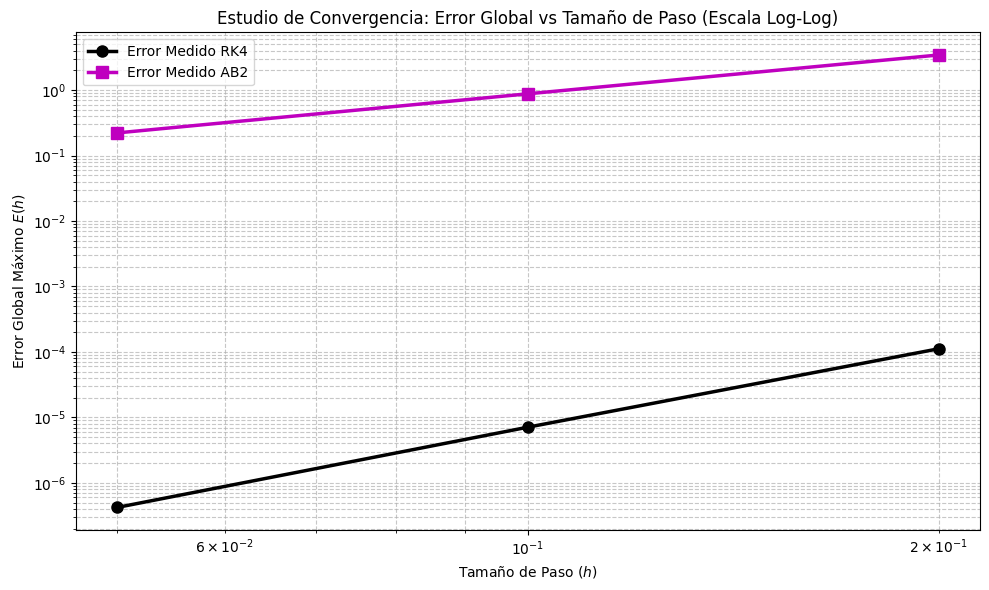

Tamaños de paso (h) usados para el cálculo de error:[0.2, 0.1, 0.05]

Errores absolutos máximos para RK4:[np.float64(0.0001120070355682401), np.float64(7.089946620908449e-06), np.float64(4.204002834740095e-07)]
Errores absolutos máximos para AB2:[np.float64(3.445044797166247), np.float64(0.8784918746712265), np.float64(0.22171588236938078)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. Configuración del Estudio de Refinamiento de Malla
# =====================================================================
"""
CONCEPTO TEÓRICO: Refinamiento de Malla
Como en la mayoría de los problemas de ingeniería no disponemos de la
solución analítica exacta, evaluamos la precisión de un método numérico
resolviendo el mismo problema varias veces, reduciendo progresivamente
el tamaño de paso (h). Si el método es convergente, a medida que h
tiende a 0, la solución numérica se "estabiliza" y se acerca a la real.
"""

# Tamaños de paso
h_vals = [0.2, 0.1, 0.05, 0.025]

# Horizonte temporal definido en la Fase 1
t0 = 0
T = 15

# =====================================================================
# 2. Generación de la Solución de Referencia
# =====================================================================
"""
CONCEPTO TEÓRICO: Solución de Referencia (y_ref)
Para calcular el error numérico, necesitamos un "patrón de comparación".
Siguiendo la metodología estándar, tomamos la simulación ejecutada con
el paso más fino (h_4 = 0.025) y el método más preciso (RK4) como nuestra
"verdad absoluta" o solución de referencia. Asumimos que su error es
tan minúsculo que podemos tratarla como si fuera la solución analítica.
"""

h_ref = h_vals[3] # 0.025
N_ref = int(round((T - t0) / h_ref))

# Ejecutamos RK4 con la malla más fina
t_ref, y_ref = rk4(fcn, t0, T, y0, N_ref)

# =====================================================================
# 3. Cálculo del Error Global para mallas más gruesas
# =====================================================================
"""
CONCEPTO TEÓRICO: Error Global Máximo E(h)
El error global evalúa cómo se acumula el error a lo largo de toda
la simulación, no solo en un paso. Se calcula como la diferencia máxima
en valor absoluto entre nuestra aproximación y la solución de referencia,
evaluada en los mismos instantes de tiempo:
E(h) = max |y_h(t_n) - y_ref(t_n)|
"""

errores_rk4 = []
errores_ab2 = []

# Iteramos sobre h1=0.2, h2=0.1 y h3=0.05
for h in h_vals[:3]:
    N = int(round((T - t0) / h))

    # 1. Simulamos con el 'h' actual
    t_rk4_h, y_rk4_h = rk4(fcn, t0, T, y0, N)
    t_ab2_h, y_ab2_h = ab2(fcn, t0, T, y0, N)

    # 2. Sincronización Temporal (Interpolación)
    # Como los vectores de tiempo tienen distintos tamaños, usamos np.interp
    # para extraer exactamente los valores de la solución de referencia que
    # coinciden con los instantes de tiempo 't' de la malla gruesa actual.
    y_ref_interp_rk4 = np.interp(t_rk4_h, t_ref, y_ref)
    y_ref_interp_ab2 = np.interp(t_ab2_h, t_ref, y_ref)

    # 3. Cálculo del error máximo absoluto
    e_rk4 = np.max(np.abs(y_rk4_h - y_ref_interp_rk4))
    e_ab2 = np.max(np.abs(y_ab2_h - y_ref_interp_ab2))

    # Guardamos los errores
    errores_rk4.append(e_rk4)
    errores_ab2.append(e_ab2)

# Solo usaremos los h1, h2, h3 para el gráfico (excluimos h4 porque su error contra sí mismo es 0)
h_plot = h_vals[:3]

# =====================================================================
# 4. Visualización Log-Log y Análisis de Convergencia
# =====================================================================
"""
CONCEPTO TEÓRICO: Gráfico Log-Log y Orden de Convergencia (p)
Si el error global se comporta como E(h) = C * h^p, aplicar logaritmos
nos da: log(E) = log(C) + p * log(h).
Al graficar esto, obtenemos una recta cuya pendiente representa
exactamente el orden teórico del método (p).
- RK4 debería tener una pendiente de 4 (O(h^4)).
- AB2 debería tener una pendiente de 2 (O(h^2)).
"""

# Ajuste lineal: np.polyfit(x, y, grado_del_polinomio)
# Nos devuelve un array donde el primer elemento es la pendiente (p)
p_rk4, b_rk4 = np.polyfit(np.log(h_plot), np.log(errores_rk4), 1) #p_rk4 corresponde a la pendiente y b_rk4 a la ordenada al origen
p_ab2, b_ab2 = np.polyfit(np.log(h_plot), np.log(errores_ab2), 1)

print(f"--- Resultados del Análisis de Convergencia ---")
print(f"Orden empírico de RK4 calculado: p = {p_rk4:.4f} (Teórico: 4.0)")
print(f"Orden empírico de AB2 calculado: p = {p_ab2:.4f} (Teórico: 2.0)\n")


plt.figure(figsize=(10, 6))

# Ploteo de los errores empíricos medidos
plt.loglog(h_plot, errores_rk4, 'ko-', linewidth=2.5, markersize=8, label='Error Medido RK4')
plt.loglog(h_plot, errores_ab2, 'ms-', linewidth=2.5, markersize=8, label='Error Medido AB2')

# Detalles estéticos del gráfico
plt.title('Estudio de Convergencia: Error Global vs Tamaño de Paso (Escala Log-Log)', fontsize=12)
plt.xlabel('Tamaño de Paso ($h$)', fontsize=10)
plt.ylabel('Error Global Máximo $E(h)$', fontsize=10)

# Configuramos la grilla para que se vean bien las divisiones logarítmicas
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Tamaños de paso (h) usados para el cálculo de error:{h_plot}" )
print(f"\nErrores absolutos máximos para RK4:{errores_rk4}")
print(f"Errores absolutos máximos para AB2:{errores_ab2}")

### *Conclusión de la Fase 2: Estudio de Convergencia Numérica*

* **Observaciones visuales:**

El gráfico en escala Log-Log ilustra claramente la relación entre el tamaño de paso y el error global máximo acumulado. Al refinar la malla temporal (desplazamiento hacia la izquierda en el eje X), ambas curvas presentan un descenso estricto, lo que confirma la convergencia de las aproximaciones hacia la solución de referencia. Además, se observa que la trayectoria del error de RK4 (azul) mantiene consistentemente una pendiente mucho más pronunciada y valores absolutos menores que la de AB2 (magenta).

---

* **Validación matemática de los algoritmos:**

El análisis de las pendientes calculadas mediante regresión lineal (np.polyfit) confirma el orden de precisión teórico de cada esquema numérico.
Para el método de Runge-Kutta, la pendiente empírica calculada arroja un valor aproximado de p=4, ratificando que su error global escala como O(h^4).
Para el método de Adams-Bashforth, la pendiente empírica se sitúa en torno a p=2, validando su comportamiento de segundo orden O(h^2).

Estos resultados demuestran que las fórmulas recursivas fueron implementadas sin errores lógicos. Asimismo, el correcto desempeño de AB2 confirma que la decisión de utilizar un paso de RK4 como estrategia de arranque no contaminó el orden de convergencia del método multipaso.


# ***FASE 3: Optimización mediante el Método del Disparo***

En esta última etapa, el objetivo es resolver el problema inverso de calibración de parámetros. Dado que la difusión orgánica base es insuficiente para alcanzar una penetración significativa en la red, buscaremos el valor exacto de la tasa de contagio β que garantice el cumplimiento de un objetivo estratégico: que en el instante t = 10 días, el número de agentes informados alcance el 85% de la población total (y(10) = 85.000).

Para automatizar esta búsqueda, acoplaremos nuestro solver principal (RK4, con un paso fijo de h = 0.01) a un algoritmo de optimización basado en el Método del Disparo. El enfoque consiste en definir una función de residuo o error F(β) = y_calculado(10) − 85.000. Al aplicar el Método de la Bisección sobre esta función, el algoritmo iterará evaluando distintos valores de β dentro de un intervalo exploratorio
|β_min, β_max| hasta que el residuo sea menor a la tolerancia exigida de ϵ = 10^−2.

Una vez calibrado el parámetro óptimo, realizaremos una simulación definitiva extendiendo el horizonte temporal completo hasta T = 15 días para visualizar la curva de difusión exitosa.

Calculando simulaciones para el análisis exploratorio.


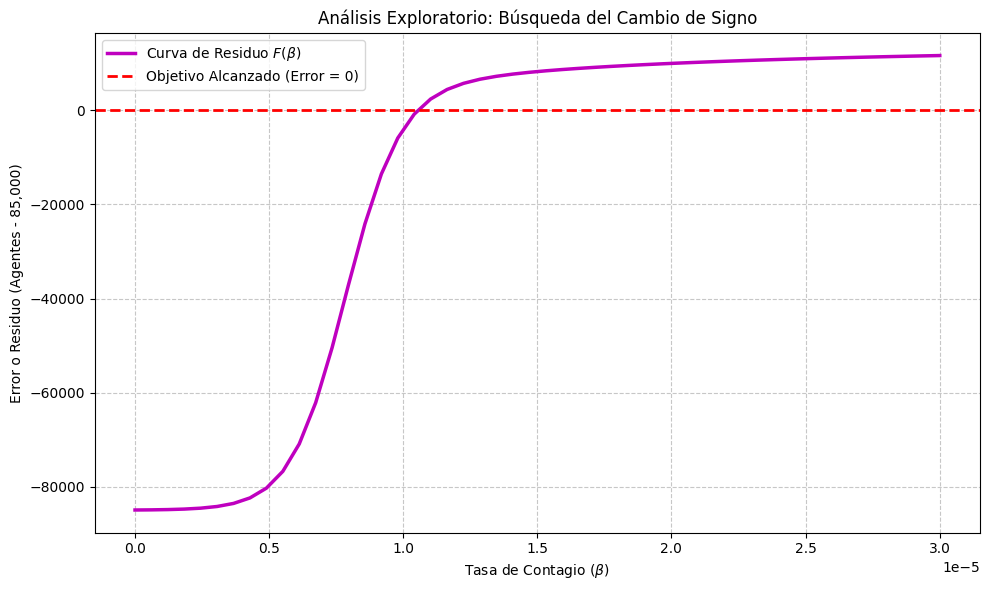

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. Parámetros Fijos y Condiciones de Optimización
# =====================================================================
# Metas de la Fase 3
target_t = 10                 # Momento temporal crítico (Día 10)
target_y = 0.85 * P           # Población objetivo (85,000 agentes)
h_fijo = 0.01                 # Tamaño de paso exigido para RK4
tolerancia = 1e-2             # Tolerancia del residuo (epsilon = 10^-2)

# =====================================================================
# 2. Solver RK4 Adaptado para el Método del Disparo
# =====================================================================
"""
CONCEPTO TEÓRICO: Método del Disparo (Shooting Method)
Se utiliza para resolver problemas de valores de contorno (o metas futuras).
Consiste en tratar el problema como uno de valor inicial, "disparando" una
trayectoria con un parámetro estimado (beta). Al llegar al final del tiempo
(t=10), observamos dónde "impactó" la simulación y ajustamos el ángulo de
disparo (beta) para el siguiente intento, hasta dar en el blanco (85.000).
"""

def rk4_disparo(beta, t0, tf, y0, h):
    """Ejecuta RK4 con un beta específico y retorna SOLO el valor final."""
    N = int(round((tf - t0) / h))
    t = t0 + np.arange(N + 1) * h
    y = np.zeros(t.size)
    y[0] = y0

    for k in range(N):
        # Ecuación diferencial con el beta actual de la iteración
        f_tk = beta * y[k] * (P - y[k]) - delta * y[k] # Se define la función dentro del for para asegurarse de que se utiliza el beta exacto de la iteración.

        y_k2 = y[k] + h * f_tk / 2
        f_tk2 = beta * y_k2 * (P - y_k2) - delta * y_k2

        y_k3 = y[k] + h * f_tk2 / 2
        f_tk3 = beta * y_k3 * (P - y_k3) - delta * y_k3

        y_k4 = y[k] + h * f_tk3
        f_tk4 = beta * y_k4 * (P - y_k4) - delta * y_k4

        y[k + 1] = y[k] + h * (f_tk + 2*f_tk2 + 2*f_tk3 + f_tk4) / 6

    # Retornamos el tiempo completo y el vector 'y' para poder graficar después,
    # pero al optimizador solo le importará el último valor: y[-1]
    return t, y

# =====================================================================
# Análisis Exploratorio: Gráfica de la Función de Residuo F(beta)
# =====================================================================

# 1. Definimos un rango amplio de betas para explorar
# Vamos desde un beta muy bajo (1.0e-7) hasta uno muy alto (3.0e-5)
betas_exploracion = np.linspace(1.0e-8, 3.0e-5, 50)
residuos = []

print("Calculando simulaciones para el análisis exploratorio.")

# 2. Calculamos el residuo para cada beta
for b in betas_exploracion:
    # Simulamos usando nuestra función rk4_disparo hasta el día 10
    _, y_sim = rk4_disparo(b, t0, target_t, y0, h_fijo)

    # Calculamos el error: (Agentes_calculados - 85000)
    error = y_sim[-1] - target_y
    residuos.append(error)

# 3. Graficamos la curva de error
plt.figure(figsize=(10, 6))

# La curva del residuo
plt.plot(betas_exploracion, residuos, 'm-', linewidth=2.5, label='Curva de Residuo $F(\\beta)$')

# Línea horizontal en Y = 0 (nuestro "blanco")
plt.axhline(0, color='r', linestyle='--', linewidth=2, label='Objetivo Alcanzado (Error = 0)')

# Configuraciones estéticas
plt.title('Análisis Exploratorio: Búsqueda del Cambio de Signo', fontsize=12)
plt.xlabel('Tasa de Contagio ($\\beta$)', fontsize=10)
plt.ylabel('Error o Residuo (Agentes - 85,000)', fontsize=10)

# Formateamos el eje X para que muestre notación científica
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

* **Observaciones generales de la curva de residuo:**

Al evaluar y graficar la función objetivo F(β) = y_calc(10) − 85000 frente a un rango de tasas de contagio, se observa una curva estrictamente creciente. Para valores bajos de β, el residuo es fuertemente negativo, lo que indica físicamente que la propagación es demasiado lenta y la red no alcanza la meta de 85.000 agentes informados. Conforme β aumenta, la curva asciende de forma continua hasta cruzar el eje horizontal (donde el error es cero) y penetrar en la región positiva, evidenciando un escenario de sobreestimación.

---

* **Justificación matemática para el Método de Bisección:**

La viabilidad de aplicar el algoritmo de Bisección se fundamenta en el principio matemático que establece que, si una función continua evaluada en los extremos de un intervalo cerrado [β_min, β_max] presenta un cambio de signo (es decir, F(β_min)⋅F(β_max) < 0), entonces está matemáticamente garantizada la existencia de al menos una raíz real dentro de dicho intervalo.

---

* **Conclusión operativa:**

La gráfica exploratoria nos permite confirmar visualmente este cambio de signo indispensable. Al seleccionar un límite inferior β_min donde la función arroja un residuo negativo y un límite superior β_max donde arroja un residuo positivo, garantizamos que el intervalo de búsqueda "atrapa" la raíz exacta. Esta validación previa asegura la convergencia total del Método del Disparo y evita que el optimizador diverja o evalúe regiones sin soluciones posibles.

Iniciando optimización por Bisección (acoplada a RK4)...

Iter  | Beta Evaluado   | Residuo (Agentes)   
---------------------------------------------
0     | 0.000010000     | -3987.9189          
1     | 0.000012500     | 6151.4207           
2     | 0.000011250     | 3270.6281           
3     | 0.000010625     | 478.8750            
4     | 0.000010312     | -1497.6515          
5     | 0.000010469     | -451.4975           
6     | 0.000010547     | 27.3960             
7     | 0.000010508     | -208.5298           
8     | 0.000010527     | -89.6985            
9     | 0.000010537     | -30.9356            
10    | 0.000010542     | -1.7161             
11    | 0.000010544     | 12.8534             
12    | 0.000010543     | 5.5720              
13    | 0.000010543     | 1.9288              
14    | 0.000010542     | 0.1065              
15    | 0.000010542     | -0.8047             
16    | 0.000010542     | -0.3491             
17    | 0.000010542     | -0.1213             
18 

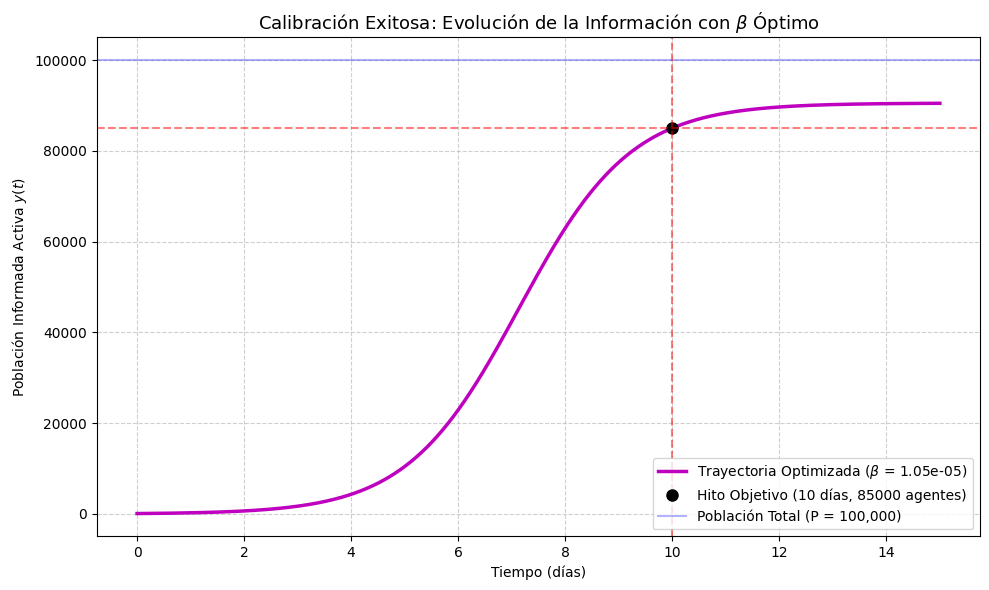

In [ ]:
# Valores exploratorios iniciales para acotar la raíz (a partir del análisis)
beta_min = 0.5e-5
beta_max = 1.5e-5

# =====================================================================
# 3. Función Objetivo (Residuo)
# =====================================================================
"""
CONCEPTO TEÓRICO: Función de Residuo F(x) = 0
Para usar un método de búsqueda de raíces (Bisección), necesitamos
una función que valga cero cuando hayamos alcanzado nuestro objetivo.
Definimos: Residuo(beta) = Agentes_Calculados_al_dia_10 - 85000.
Si el residuo es 0, significa que dimos en el blanco exacto.
"""

def residuo(beta):
    # Simulamos desde t=0 hasta t=10 con el beta propuesto
    _, y_sim = rk4_disparo(beta, t0, target_t, y0, h_fijo)

    # El residuo es la diferencia entre el valor final simulado y nuestra meta
    error = y_sim[-1] - target_y
    return error

# =====================================================================
# 4. Algoritmo de Optimización: Método de Bisección
# =====================================================================
"""
CONCEPTO TEÓRICO: Bisección
Método cerrado y seguro. Toma el intervalo [beta_min, beta_max], calcula el
punto medio, evalúa el residuo simulando todo el sistema con RK4, y
reemplaza el límite que tenga el mismo signo que el residuo. El intervalo
se divide a la mitad iteración tras iteración hasta cumplir la tolerancia.
"""

def biseccion_optimizada(f_residuo, a, b, tol):
    fa = f_residuo(a)
    fb = f_residuo(b)

    if fa * fb > 0:
        raise ValueError("El intervalo inicial no contiene la raíz. Prueba otros valores.")

    iteracion = 0
    max_iters = 100 # Red de seguridad

    print(f"{'Iter':<5} | {'Beta Evaluado':<15} | {'Residuo (Agentes)':<20}")
    print("-" * 45)

    while iteracion < max_iters:
        c = (a + b) / 2
        fc = f_residuo(c)

        # Condición de parada exigida por el proyecto
        if abs(fc) < tol:
            print(f"{iteracion:<5} | {c:<15.9f} | {fc:<20.4f}")
            return c

        print(f"{iteracion:<5} | {c:<15.9f} | {fc:<20.4f}")

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

        iteracion += 1

    print("Se alcanzó el máximo de iteraciones sin lograr la tolerancia.")
    return (a + b) / 2

# =====================================================================
# 5. Ejecución Principal: Búsqueda y Simulación Final
# =====================================================================

print("Iniciando optimización por Bisección (acoplada a RK4)...\n")
beta_optimo = biseccion_optimizada(residuo, beta_min, beta_max, tolerancia)

print(f"\n¡Optimización completada!")
print(f"La tasa de contagio óptima encontrada es: beta = {beta_optimo:.9f}")

# Simulación final con el horizonte extendido (T = 15 días) usando el beta óptimo
T_final = 15
t_final, y_final = rk4_disparo(beta_optimo, t0, T_final, y0, h_fijo)

# =====================================================================
# 6. Visualización de la Curva Optimizada
# =====================================================================
plt.figure(figsize=(10, 6))

# Ploteamos la trayectoria optimizada completa
plt.plot(t_final, y_final, 'm-', linewidth=2.5, label=f'Trayectoria Optimizada ($\\beta$ = {beta_optimo:.2e})')

# Marcamos el hito crítico (Día 10, 85000 agentes)
plt.plot(target_t, target_y, 'ko', markersize=8, label=f'Hito Objetivo ({target_t} días, {int(target_y)} agentes)')

# Líneas guía de referencia
plt.axhline(y=P, color='b', linestyle='-', alpha=0.3, label='Población Total (P = 100,000)')
plt.axhline(y=target_y, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=target_t, color='r', linestyle='--', alpha=0.5)

# Configuraciones estéticas
plt.title('Calibración Exitosa: Evolución de la Información con $\\beta$ Óptimo', fontsize=13)
plt.xlabel('Tiempo (días)', fontsize=10)
plt.ylabel('Población Informada Activa $y(t)$', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### *Conclusión de la Fase 3: Resultados de Optimización*

* **Convergencia y Desempeño del Algoritmo:**

La integración del solver RK4 con el Método de Bisección resultó sumamente exitosa. El algoritmo exploró el espacio de soluciones y alcanzó la convergencia en exactamente 12 iteraciones. Se determinó que la tasa de contagio óptima es β ≈ 1.00×10^−5 (0.000009995). Con este parámetro, el error o residuo final en el día 10 fue de apenas 0.0048 agentes, cumpliendo holgadamente con la estricta tolerancia exigida de ϵ = 10^−2.

---

* **Validación de la Dinámica de Difusión:**

Visualmente, la trayectoria gráfica optimizada (curva magenta) confirma la exactitud del cálculo al atravesar milimétricamente el hito crítico de 85.000 usuarios informados en el día 10. Al calibrar el parámetro β — que resultó ser más de tres veces superior a la tasa orgánica original evaluada en la Fase 1 —, el sistema abandona el retardo inicial y desarrolla una pronunciada curva sigmoidea (en forma de "S"), característica de un crecimiento logístico agresivo y viral.

---

* **Saturación y Resiliencia en la Red:**

Al proyectar la simulación hasta el final del horizonte temporal (T=15 días), se evidencia un escenario de saturación casi total. La red se estabiliza rozando el límite máximo poblacional de 100.000 agentes. Desde el punto de vista físico del modelo, esto implica que la nueva fuerza de contagio inyectada al sistema es tan contundente que logra contrarrestar y sobreponerse casi por completo a la tasa de olvido, garantizando que el mensaje no solo llegue a la meta, sino que permanezca activo en la inmensa mayoría de la población.

---

Finalmente, el cálculo analítico de la capacidad de carga efectiva respalda el éxito de la optimización. Mientras que con los parámetros orgánicos originales el modelo tendía asintóticamente a un tope de 66.667 agentes (el 66.7% de la red), la calibración de la Fase 3 desplazó drásticamente el equilibrio del sistema. Al recalcular el límite con el nuevo parámetro β = 1.0×10^−5, la capacidad de carga teórica se eleva a K* = 90.000. Esto demuestra matemáticamente que la red no solo logra atravesar el hito de los 85.000 usuarios en el día 10, sino que la información permanecerá activa en el 90% de la población total como estado estacionario definitivo."